In [1]:
import scripts.src.modelos as mod
import numpy as np
import json
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [2]:
def modelComparison(results, baseline):
    deltaBIC = {}
    deltaZ = {}
    for i in results.keys():
        delta1 = results[i]["BIC"]["value"] - results[baseline]["BIC"]["value"]
        delta2 = results[i]["logZ"]["mean"] - results[baseline]["logZ"]["mean"]
        deltaBIC.update({i:{delta1}})
        deltaZ.update({i:{delta2}})

    print(f"Delta logZ ({baseline})")
    for i in results.keys():
        if abs(list(deltaZ[i])[0]) == 0: texto = "Referência"
        elif abs(list(deltaZ[i])[0]) < 1: texto = "Evidência fraca/Inconclusivo"
        elif abs(list(deltaZ[i])[0]) < 3: texto = "Evidência moderada"
        elif abs(list(deltaZ[i])[0]) < 5: texto = "Evidência forte"
        elif abs(list(deltaZ[i])[0]) > 5: texto = "Evidência muito forte"
        if list(deltaZ[i])[0] < 0: texto += f" em favor de {baseline}"
        elif list(deltaZ[i])[0] > 0: texto += f" em favor de {i}"
        print(f"{i} = {np.round(list(deltaZ[i])[0],3)} ({texto})")

    print(f"\nDelta BIC ({baseline})")
    for i in results.keys():
        if list(deltaBIC[i])[0] == 0: texto = "Referência"
        elif list(deltaBIC[i])[0] < 2: texto = "Evidência fraca/Inconclusivo"
        elif list(deltaBIC[i])[0] < 6: texto = "Evidência moderada"
        elif list(deltaBIC[i])[0] < 10: texto = "Evidência forte"
        elif list(deltaBIC[i])[0] > 10: texto = "Evidência muito forte"
        print(f"{i} = {np.round(list(deltaBIC[i])[0],3)} ({texto})")

In [3]:
def HzLCDM(z, theta):
    H0, Om = theta
    return H0*np.sqrt(Om*(1+z)**3+1-Om)
    
def Ez(z, dc, Om):
    return 1/np.sqrt(Om*(1+z)**3+1-Om)

def DcLCDM(z, theta):
    H0, Om = theta
    sol = solve_ivp(Ez, [z[0],z[-1]], [0.0], t_eval=z, args=(Om,), method='RK45')

    return sol.y[0]

In [4]:
planck = [67.4, 0.315]
sh0es = [73.6, 0.334]

In [5]:
z = np.linspace(0, 15, 2000)
DcPlanck = DcLCDM(z, planck)
HzPlanck = HzLCDM(z, planck)

DcSh0es = DcLCDM(z, sh0es)
HzSh0es = HzLCDM(z, sh0es)

In [6]:
modelos = ["P21", "P22", "P31", "P32"]
data = ["PP", "PS"]

In [10]:
path_PP = []
path_PS = []

for i in modelos:
    if "PP" in data:
        path_PP.append(f"scripts/resultados/{i}/PP/resultado_{i}_PP.json")
    if "PS" in data:
        path_PS.append(f"scripts/resultados/{i}/PS/resultado_{i}_PS.json")

In [11]:
results_PP = {}
results_PS = {}

In [12]:
if "PP" in data:
    for path, i in zip(path_PP, modelos):
        with open(path,'r') as f:
            results_PP.update({i: json.load(f)})
if "PS" in data:    
    for path, i in zip(path_PS, modelos):
        with open(path,'r') as f:
            results_PS.update({i: json.load(f)})

In [13]:
values_PP = {}
values_PS = {}

In [14]:
for i in modelos:
    if "PP" in data:
        values_PP.update({i:{"params":{}}})
    if "PS" in data:
        values_PS.update({i:{"params":{}}})
        
    for j in results_PP[i]["params"].keys():
        if "PP" in data:
            values_PP[i]["params"].update({j: results_PP[i]["params"][j]["mean"]})
        if "PS" in data:
            values_PS[i]["params"].update({j: results_PS[i]["params"][j]["mean"]})

In [15]:
for i in modelos:
    if "PP" in data:
        values_PP[i].update({"Dc": mod.MODELOS[i]["Dc"](z, list(values_PP[i]["params"].values()))})
        values_PP[i].update({"Hz": values_PP[i]["params"]["h0"]*mod.MODELOS[i]["Ez"](z, list(values_PP[i]["params"].values()))})
    if "PS" in data:
        values_PS[i].update({"Dc": mod.MODELOS[i]["Dc"](z, list(values_PS[i]["params"].values()))})
        values_PS[i].update({"Hz": values_PS[i]["params"]["h0"]*mod.MODELOS[i]["Ez"](z, list(values_PS[i]["params"].values()))})

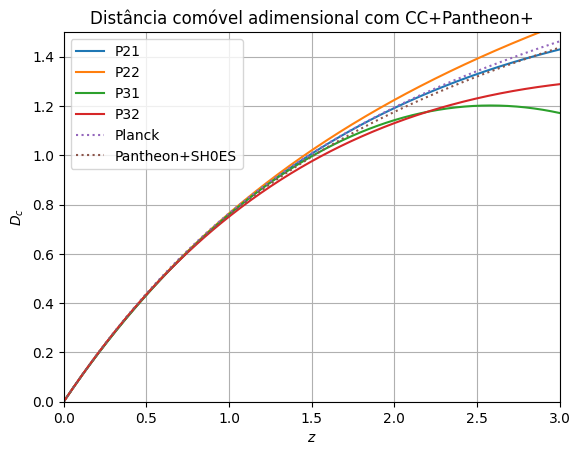

In [16]:
for i in modelos:
    plt.plot(z, values_PP[i]["Dc"], label=i)
#plt.plot(z, values_PP["P22"]["Dc"], label=i)
plt.plot(z, DcLCDM(z,planck), linestyle=":", label="Planck")
plt.plot(z, DcLCDM(z,sh0es), linestyle=":", label="Pantheon+SH0ES")

plt.xlim(0, 3)
plt.ylim(0, 1.5)
plt.xlabel("$z$")
plt.ylabel("$D_{c}$")
plt.title("Distância comóvel adimensional com CC+Pantheon+")
plt.grid()
plt.legend()
plt.show()

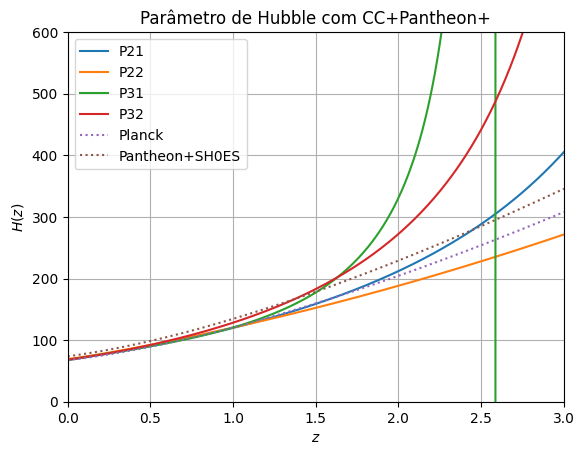

In [17]:
for i in modelos:
    plt.plot(z, values_PP[i]["Hz"], label=i)
#plt.plot(z, values_PP["P22"]["Hz"], label=i)
plt.plot(z, HzLCDM(z, planck), linestyle=":", label="Planck")
plt.plot(z, HzLCDM(z, sh0es), linestyle=":", label="Pantheon+SH0ES")

plt.xlim(0, 3)
plt.ylim(0, 600)
plt.xlabel("$z$")
plt.ylabel("$H(z)$")
plt.title("Parâmetro de Hubble com CC+Pantheon+")
plt.grid()
plt.legend()
plt.show()

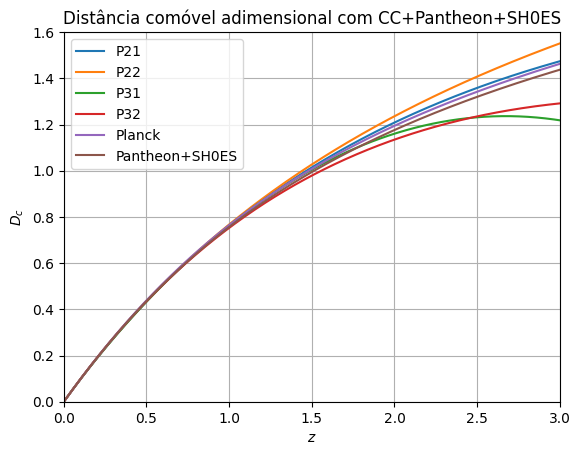

In [18]:
for i in modelos:
    plt.plot(z, values_PS[i]["Dc"], label=i)
plt.plot(z, DcLCDM(z,planck), label="Planck")
plt.plot(z, DcLCDM(z,sh0es), label="Pantheon+SH0ES")

plt.xlim(0, 3)
plt.ylim(0, 1.6)
plt.xlabel("$z$")
plt.ylabel("$D_{c}$")
plt.title("Distância comóvel adimensional com CC+Pantheon+SH0ES")
plt.grid()
plt.legend()
plt.show()

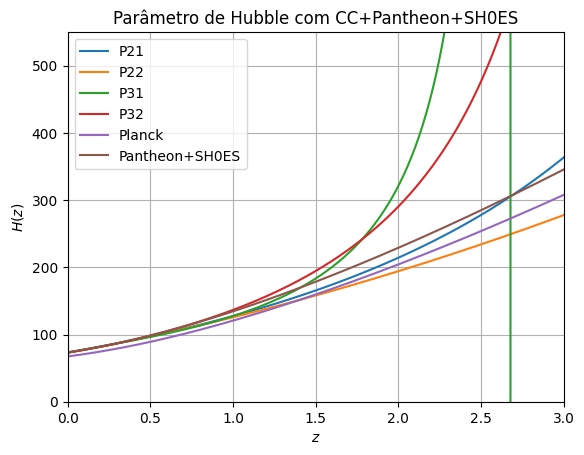

In [19]:
for i in modelos:
    plt.plot(z, values_PS[i]["Hz"], label=i)
plt.plot(z, HzLCDM(z, planck), label="Planck")
plt.plot(z, HzLCDM(z, sh0es), label="Pantheon+SH0ES")

plt.xlim(0, 3)
plt.ylim(0, 550)
plt.xlabel("$z$")
plt.ylabel("$H(z)$")
plt.title("Parâmetro de Hubble com CC+Pantheon+SH0ES")
plt.grid()
plt.legend()
plt.show()

In [20]:
if "PP" in data:
    print("-"*30)
    print("CC+Pantheon+")
    print("-"*30)
    modelComparison(results_PP, "P21")

if "PS" in data:
    print("\n\n"+"-"*30)
    print("CC+Pantheon+SH0ES")
    print("-"*30)
    modelComparison(results_PS, "P21")

------------------------------
CC+Pantheon+
------------------------------
Delta logZ (P21)
P21 = 0.0 (Referência)
P22 = 2.481 (Evidência moderada em favor de P22)
P31 = -2.251 (Evidência moderada em favor de P21)
P32 = -0.91 (Evidência fraca/Inconclusivo em favor de P21)

Delta BIC (P21)
P21 = 0.0 (Referência)
P22 = 6.638 (Evidência forte)
P31 = 6.418 (Evidência forte)
P32 = 13.913 (Evidência muito forte)


------------------------------
CC+Pantheon+SH0ES
------------------------------
Delta logZ (P21)
P21 = 0.0 (Referência)
P22 = 3.277 (Evidência forte em favor de P22)
P31 = -2.472 (Evidência moderada em favor de P21)
P32 = -0.47 (Evidência fraca/Inconclusivo em favor de P21)

Delta BIC (P21)
P21 = 0.0 (Referência)
P22 = 0.46 (Evidência fraca/Inconclusivo)
P31 = 6.541 (Evidência forte)
P32 = 14.013 (Evidência muito forte)


In [32]:
import numpy as np
import src.modelos as mod_novo
import src.estatistica as est_novo
import src.data_loader as dl_novo

# --- 1. CONFIGURAÇÃO ---
# Escolha um ponto de teste (longe de zero)
# Theta = [M, H0, q0, j0]
theta_teste = [-0.1238608212738987, 67.98182364336468, -0.40847591457323007, 0.4533204140973241] 

print(f"--- Iniciando Verificação para P21 em {theta_teste} ---")

# --- 2. CÁLCULO PELO SCRIPT NOVO ---
print("\n>>> Calculando pelo Código NOVO...")
dados_cc = dl_novo.load_chronometers("data/32CCdata.dat", "data/data_MM20.dat")
dados_pp = dl_novo.load_pantheon("data/Pantheon+SH0ES.dat", "data/Pantheon+SH0ES_STAT+SYS.cov", SH0ES=False)
data_pack = {"CC": dados_cc, "SNe": dados_pp}

# Chama a função lnprob do script novo
lnlike_novo = est_novo.lnprob(theta_teste, "P21", data_pack)
print(f"LnLike NOVO: {lnlike_novo:.10f}")
print(f"chi2min NOVO: {-2*lnlike_novo:.10f}")


# --- 3. CÁLCULO PELO CÓDIGO ANTIGO (Copiado do seu Notebook) ---
print("\n>>> Calculando pelo Código ANTIGO...")

# (Copiei suas funções antigas aqui para garantir isolamento)
c = 299792.458
def EzP21_old(z, theta):
    M, H0, q0, j0 = theta
    a1 = 1/H0
    a2 = (1 -2 * j0 + 2 * q0 + 3 * (q0 ** 2))/(6*H0*(1 + q0))
    b1 = (2 -j0 + 4 * q0 + 3 * (q0 ** 2))/(3*(1 + q0))
    hz = ((1 + b1 * z) ** 2) / (a1 + a2 * z * (2 + b1 * z))
    return hz/H0

def dmModelP21_old(z, theta): # Seu dmModel original (que é Comóvel)
    M, H0, q0, j0 = theta
    a1 = 1/H0
    a2 = (1 -2 * j0 + 2 * q0 + 3 * (q0 ** 2))/(6*H0*(1 + q0))
    b1 = (2 -j0 + 4 * q0 + 3 * (q0 ** 2))/(3*(1 + q0))
    dc = (a1*z+a2*z**2)/(1+b1*z)
    Dcm = H0*dc
    return (c/H0)*Dcm 

def daModelP21_old(z, theta): # Seu daModel original
    return dmModelP21_old(z, theta)/(1+z)

# Seus dados carregados (usando o loader novo pq é igual)
zHz = dados_cc['z']
Hzi = dados_cc['Hz']
inv_cov_mat = dados_cc['inv_cov']
zCMBPPlus = dados_pp['z']
zHELPPlus = dados_pp['zHEL']
m_obsPPlus = dados_pp['m_obs']
invcovPPlus = dados_pp['inv_cov']
zt = np.linspace(0,2.5, 3000)

import scipy.interpolate
def extract_old(theory_x, theory_y, pars):
    M = pars[0]
    f = scipy.interpolate.interp1d(theory_x, theory_y)
    zcmb = zCMBPPlus
    zhel = zHELPPlus
    fz = f(zcmb)
    # A fórmula original do seu notebook
    theory_ynew = 5.0*np.log10((1.0+zcmb)*(1.0+zhel)*np.atleast_1d(fz))+25.
    return theory_ynew + M

def extract_hz_old(theory_x, theory_y):
    f = scipy.interpolate.interp1d(theory_x, theory_y)
    return np.atleast_1d(f(zHz))

def chi2Hz_old(theta):
    M, H0, q0, j0 = theta
    Ezt = EzP21_old(zt, theta)
    if np.any(Ezt<0): return np.inf
    Hzt = H0*Ezt
    Hzm = extract_hz_old(zt, Hzt)
    dh = Hzm-Hzi
    return np.dot(np.dot(dh.T,inv_cov_mat),dh)

def chi2PP_old(theta):
    Ez2i = EzP21_old(zCMBPPlus, theta)
    if np.any(Ez2i <= 0): return np.inf
    dAt = daModelP21_old(zt, theta) # Usa Angular
    mmod = extract_old(zt, dAt, theta) # + M
    dmu = mmod - m_obsPPlus
    SA  = np.sum(invcovPPlus)
    Sr  = np.sum(np.dot(dmu.T,invcovPPlus))
    Srr = np.dot(np.dot(dmu.T,invcovPPlus),dmu)
    return Srr - Sr**2./SA

lnlike_antigo = -0.5*(chi2Hz_old(theta_teste) + chi2PP_old(theta_teste))
print(f"LnLike ANTIGO: {lnlike_antigo:.10f}")
print(f"chi2min ANTIGO: {-2*lnlike_antigo:.10f}")

# --- 4. RESULTADO ---
diff = abs(lnlike_novo - lnlike_antigo)
print(f"\n Diferença Absoluta: {diff:.2e}")

if diff < 1e-5:
    print("✅ SUCESSO: Os códigos são matematicamente equivalentes!")
else:
    print("❌ ALERTA: Há uma diferença na implementação física.")

--- Iniciando Verificação para P21 em [-0.1238608212738987, 67.98182364336468, -0.40847591457323007, 0.4533204140973241] ---

>>> Calculando pelo Código NOVO...
LnLike NOVO: -709.0913844037
chi2min NOVO: 1418.1827688074

>>> Calculando pelo Código ANTIGO...
LnLike ANTIGO: -709.0913844037
chi2min ANTIGO: 1418.1827688074

 Diferença Absoluta: 0.00e+00
✅ SUCESSO: Os códigos são matematicamente equivalentes!
